### Base Dataset

In [1]:
import pandas as pd
import numpy as np

np.random.seed(0)

df = pd.DataFrame({
    "age": np.random.randint(18, 70, 500),
    "salary": np.random.normal(6000, 15000, 500).astype(int),
    "city": np.random.choice(["Pune", "Mumbai", "Delhi"], 500),
    "experience": np.random.randint(0, 40, 500),
    "joined_year": np.random.randint(2015, 2025, 500)
})

In [2]:
df

,age,salary,city,experience,joined_year
0,62,10819,Pune,4,2023
1,65,4141,Pune,36,2015
2,18,6331,Mumbai,19,2020
3,21,1180,Pune,17,2021
4,21,16389,Mumbai,6,2015
...,...,...,...,...,...
495,24,29905,Mumbai,5,2024
496,27,-6099,Delhi,25,2015
497,45,18494,Pune,12,2021
498,65,6727,Delhi,6,2016


### First 5 Commands of any EDA

In [3]:
df.head()

,age,salary,city,experience,joined_year
0,62,10819,Pune,4,2023
1,65,4141,Pune,36,2015
2,18,6331,Mumbai,19,2020
3,21,1180,Pune,17,2021
4,21,16389,Mumbai,6,2015


In [4]:
df.tail()

,age,salary,city,experience,joined_year
495,24,29905,Mumbai,5,2024
496,27,-6099,Delhi,25,2015
497,45,18494,Pune,12,2021
498,65,6727,Delhi,6,2016
499,53,-12920,Delhi,9,2016


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          500 non-null    int64 
 1   salary       500 non-null    int64 
 2   city         500 non-null    object
 3   experience   500 non-null    int64 
 4   joined_year  500 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 19.7+ KB


In [6]:
df.describe()

,age,salary,experience,joined_year
count,500.000000,500.000000,500.000000,500.000000
mean,43.212000,6573.280000,19.334000,2019.436000
std,15.093531,15726.095205,11.567976,2.893207
min,18.000000,-41667.000000,0.000000,2015.000000
25%,30.000000,-4274.000000,9.000000,2017.000000
50%,43.000000,6719.500000,19.000000,2019.000000
75%,56.250000,17623.000000,29.000000,2022.000000
max,69.000000,48191.000000,39.000000,2024.000000


In [7]:
df.sample(5)

,age,salary,city,experience,joined_year
408,52,-4173,Delhi,27,2016
173,66,27077,Delhi,21,2020
11,41,13868,Mumbai,2,2020
51,28,-9452,Mumbai,23,2021
248,45,24991,Mumbai,4,2019


### Univariate Analysis (One Column at a Time)
#### Numeric distributions

In [8]:
df["salary"].describe()

count      500.000000
mean      6573.280000
std      15726.095205
min     -41667.000000
25%      -4274.000000
50%       6719.500000
75%      17623.000000
max      48191.000000
Name: salary, dtype: float64

Matplotlib is building the font cache; this may take a moment.


<Axes: >

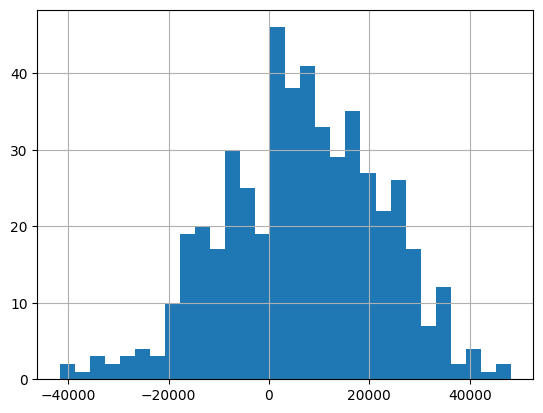

In [10]:
df["salary"].hist(bins=30)

#### Categorical distributions

In [11]:
df["city"].value_counts()

city
Mumbai    174
Pune      164
Delhi     162
Name: count, dtype: int64

In [12]:
df["city"].value_counts(normalize=True)

city
Mumbai    0.348
Pune      0.328
Delhi     0.324
Name: proportion, dtype: float64

- `normalize=True` converts counts into relative frequencies
- Values sum to 1.0

### Detecting Outliers
#### Simple statistical check

In [16]:
df[df["salary"] < 0]

,age,salary,city,experience,joined_year
7,37,-11126,Delhi,28,2021
12,24,-5900,Mumbai,9,2015
15,30,-16659,Mumbai,0,2019
16,19,-17475,Mumbai,10,2019
17,56,-39768,Pune,13,2022
...,...,...,...,...,...
481,38,-5409,Mumbai,20,2021
490,48,-6855,Pune,25,2020
492,61,-14432,Delhi,27,2020
496,27,-6099,Delhi,25,2015


In [14]:
df["salary"].quantile([0.01, 0.99])

0.01   -33340.26
0.99    40261.04
Name: salary, dtype: float64

- Computes **percentiles (quantiles)** of salary
- `0.01` -> **1st percentile**
- `0.99` -> **99th percentile**

**Interpretation**
- **1% of salaries are below** −33340.26
- **99% of salaries are below** 40261.04
- Anything outside this range is an **outlier**


> `min() / max()` -> Extremely sensitive to outliers     
> `quantile()` -> Robust, realistic boundaries

#### IQR method

In [17]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["salary"] < Q1 - 1.5 * IQR) |
    (df["salary"] > Q3 + 1.5 * IQR)
]

outliers


,age,salary,city,experience,joined_year
17,56,-39768,Pune,13,2022
34,65,-41667,Pune,28,2024
282,51,-37404,Mumbai,7,2022


### Bivariate Analysis (Feature Relationships)
#### Numeric vs Numeric

<Axes: xlabel='experience', ylabel='salary'>

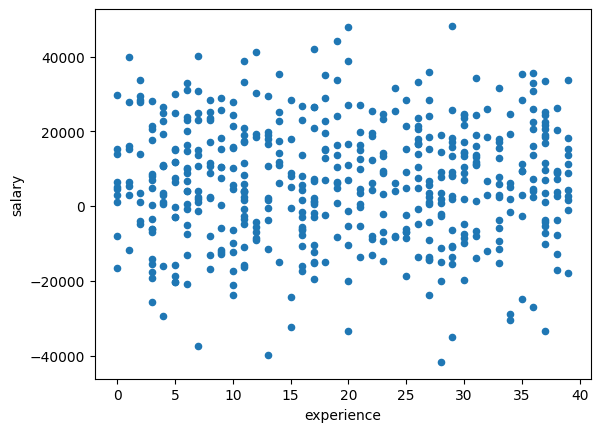

In [18]:
df.plot.scatter(x="experience", y="salary")

What to look for:
- Linear trend
- Saturation
- Non-linear patterns

#### Numeric vs Categorical

In [19]:
df.groupby("city")["salary"].mean()

city
Delhi     7657.129630
Mumbai    8142.143678
Pune      3838.121951
Name: salary, dtype: float64

<Axes: title={'center': 'salary'}, xlabel='city'>

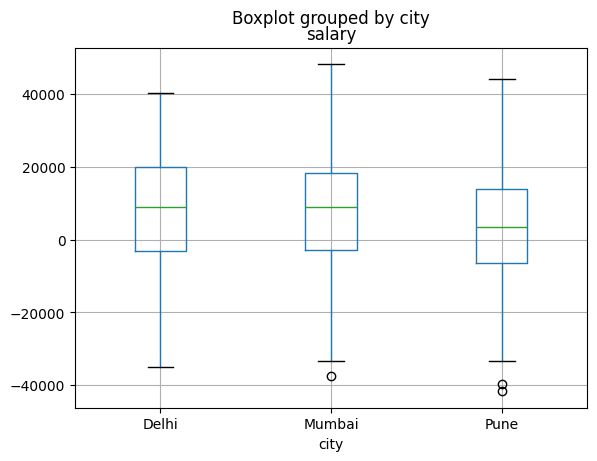

In [20]:
df.boxplot(column='salary', by="city")

### Correlation Analysis

In [21]:
df.corr(numeric_only=True)

,age,salary,experience,joined_year
age,1.000000,-0.045287,0.051472,0.094342
salary,-0.045287,1.000000,0.009923,-0.004520
experience,0.051472,0.009923,1.000000,-0.058489
joined_year,0.094342,-0.004520,-0.058489,1.000000


Correlation:
- detects linear relationships
- misses non-linear ones
- can be misleading with leakage

### Time-Aware EDA

In [23]:
df.groupby("joined_year")["salary"].mean()

joined_year
2015     8108.759259
2016     3449.857143
2017     6688.294118
2018     7595.040816
2019     6105.818182
2020     8764.434783
2021     6859.444444
2022     3172.800000
2023    11915.428571
2024     3888.109091
Name: salary, dtype: float64

In [24]:
df.groupby("joined_year").size()

joined_year
2015    54
2016    49
2017    51
2018    49
2019    55
2020    46
2021    54
2022    45
2023    42
2024    55
dtype: int64

Look for:
- Sudden jumps
- Missing years
- Distribution drift

### Pandas Built-in Plotting
Pandas plots = **Matplotlib under the hood**

<Axes: ylabel='Frequency'>

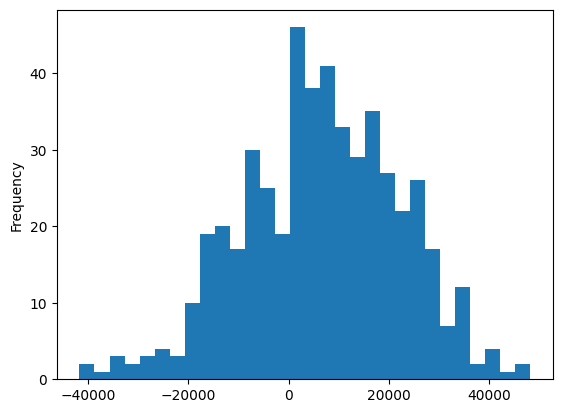

In [25]:
df["salary"].plot(kind="hist", bins=30)

<Axes: xlabel='city'>

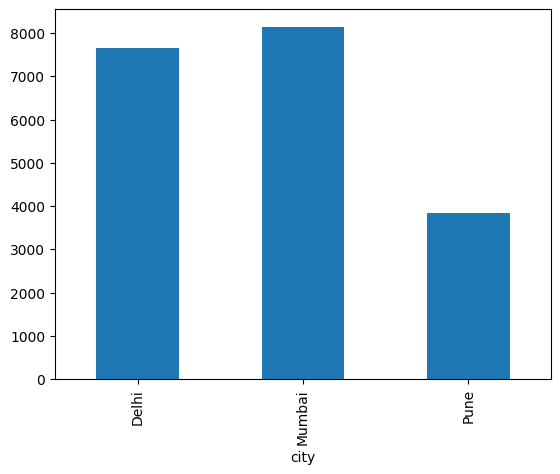

In [26]:
df.groupby("city")["salary"].mean().plot(kind="bar")

| Need                   | Tool       |
| ---------------------- | ---------- |
| Quick EDA              | Pandas     |
| Statistical viz        | Seaborn    |
| Interactive dashboards | Plotly     |
| Big data               | Datashader |


### Base Dataset

In [31]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "user_id": range(1, 501),
    "age": np.random.randint(16, 75, 500),
    "salary": np.random.normal(60000, 18000, 500).astype(int),
    "city": np.random.choice(["Pune", "Mumbai", "Delhi", "Unknown"], 500),
    "experience": np.random.randint(0, 45, 500),
    "joined_year": np.random.randint(2014, 2026, 500)
})

# introduce issues
df.loc[df.sample(10).index, "salary"] = -1          # invalid salaries
df.loc[df.sample(8).index, "age"] = 150              # impossible ages
df.loc[df.sample(6).index, "city"] = None            # missing category


### Exercise 1
1. Inspect:
```python
df.head()
df.info()
df.describe()
```
2. Answer:
   - Which columns immediately look suspicious?
   - Why?

In [32]:
df.head()

,user_id,age,salary,city,experience,joined_year
0,1,54,62970,Mumbai,13,2021
1,2,67,44593,Mumbai,28,2023
2,3,44,59286,Pune,11,2024
3,4,30,50376,Delhi,35,2020
4,5,58,27807,Pune,34,2019


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      500 non-null    int64 
 1   age          500 non-null    int64 
 2   salary       500 non-null    int64 
 3   city         494 non-null    object
 4   experience   500 non-null    int64 
 5   joined_year  500 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 23.6+ KB


In [34]:
df.describe()

,user_id,age,salary,experience,joined_year
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,46.982000,59207.110000,21.528000,2019.312000
std,144.481833,21.203321,20234.079112,12.922973,3.399672
min,1.000000,16.000000,-1.000000,0.000000,2014.000000
25%,125.750000,32.000000,48024.250000,11.000000,2016.000000
50%,250.500000,47.000000,59692.500000,21.000000,2019.000000
75%,375.250000,60.000000,73631.500000,33.000000,2022.000000
max,500.000000,150.000000,110107.000000,44.000000,2025.000000


- `age` -> max = **150** (impossible)
- `salary` -> min = **-1** (invalid)
- `city` -> missing values
- `joined_year` -> goes up to **2026** (future leakage risk)

### Exercise 2
1. Compute missing value count per column
2. Compute missing value percentage
3. Answer:
   - Which missing values are acceptable?
   - Which are not?

In [35]:
df.isna().sum()

user_id        0
age            0
salary         0
city           6
experience     0
joined_year    0
dtype: int64

In [36]:
df.isna().mean() * 100

user_id        0.0
age            0.0
salary         0.0
city           1.2
experience     0.0
joined_year    0.0
dtype: float64

**Observations**
- `city` has missing values (~1–2%)
- Numeric columns mostly complete

#### Business Interpretation
| Column     | Missing OK? | Reason                 |
| ---------- | ----------- | ---------------------- |
| user_id    | No           | Primary key            |
| age        | No           | Core demographic       |
| salary     | No           | Target / key signal    |
| city       | Maybe          | Maybe (needs decision) |
| experience | No          | Derived signal         |


### Exercise 3
**Numeric columns**
1. Plot histogram for:
- age
- salary
- experience

2. Identify:
- Skew
- Outliers
- Impossible values

**Categorical column**
1. Compute `city.value_counts()`
2. Compute normalized counts
3. Answer:
   - Is there class imbalance?
   - Why might `"Unknown"` be dangerous?

#### Numerical Distribution

<Axes: >

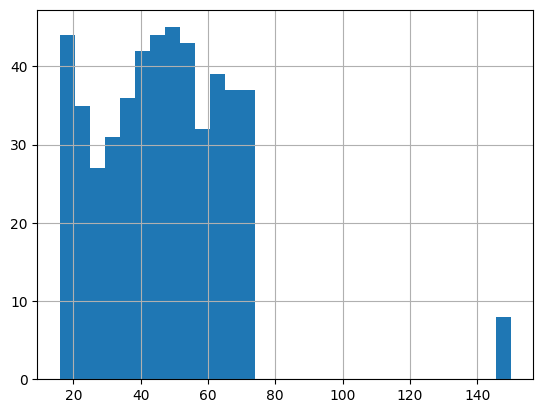

In [41]:
df["age"].hist(bins=30)

<Axes: >

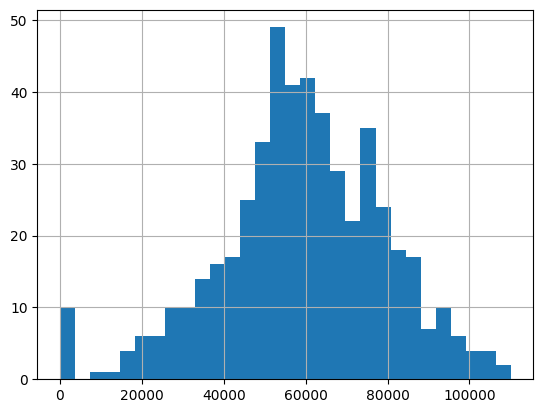

In [42]:
df["salary"].hist(bins=30)

<Axes: >

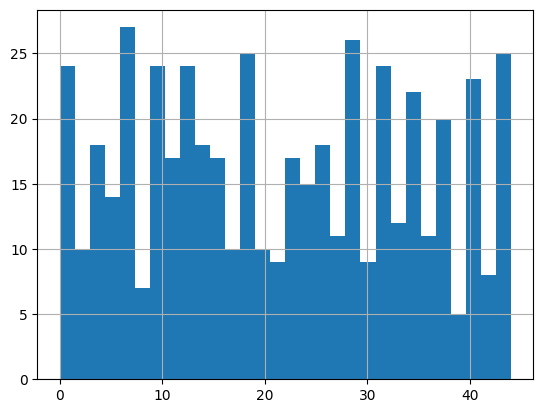

In [43]:
df["experience"].hist(bins=30)

- **Age**
    - Spike at 150 -> clearly injected bad data

- **Salary**
    - Left tail < 0 -> invalid
    - Right tail -> potential high earners

- **Experience**
    - Values > age -> logically impossible

#### Categorical Distribution

In [44]:
df["city"].value_counts()

city
Pune       137
Delhi      124
Mumbai     123
Unknown    110
Name: count, dtype: int64

In [45]:
df["city"].value_counts(normalize=True)

city
Pune       0.277328
Delhi      0.251012
Mumbai     0.248988
Unknown    0.222672
Name: proportion, dtype: float64

- `"Unknown"` is a **real category**, not missing
- Combined with `None`, this creates:
   - category ambiguity
   - grouping errors
   - ML noise

### Exercise 4
1. Use quantiles to find extreme salary values
2. Use IQR to flag salary outliers
3. Answer:
   - Are all outliers necessarily wrong?
   - Which ones are clearly invalid?

In [46]:
df["salary"].quantile([0.01, 0.99])

0.01        -1.00
0.99    103010.07
Name: salary, dtype: float64

In [48]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["salary"] < Q1 - 1.5 * IQR) |
    (df["salary"] > Q3 + 1.5 * IQR)
]

outliers

,user_id,age,salary,city,experience,joined_year
28,29,48,-1,Delhi,10,2025
36,37,74,-1,Pune,2,2014
52,53,24,-1,Mumbai,33,2020
180,181,45,-1,Pune,44,2023
211,212,43,-1,Pune,3,2016
288,289,26,-1,Delhi,42,2017
327,328,31,-1,Pune,30,2020
331,332,67,-1,Delhi,37,2015
407,408,42,-1,Delhi,6,2021
432,433,39,-1,Mumbai,27,2024


- Salary = -1 -> **invalid**
- Very high salaries -> **possible**

### Exercise 5
1. Salary vs experience:
   - Scatter plot
   - What trend do you see?
2. Salary by city:
   - Boxplot
   - Which city looks suspicious?

<Axes: xlabel='experience', ylabel='salary'>

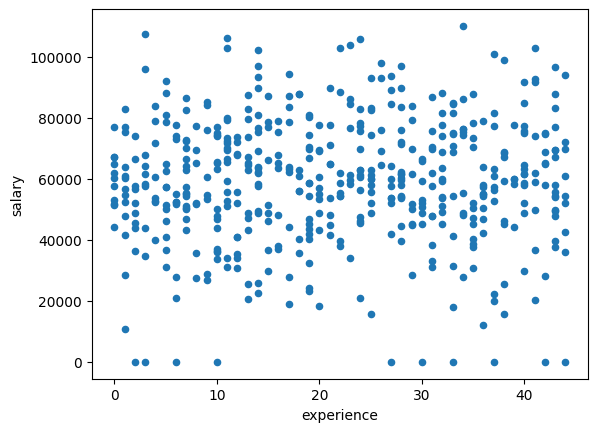

In [49]:
df.plot.scatter(x="experience", y="salary")

**Observation**
- Weak positive trend
- High variance -> salary depends on more than experience
- Some points violate logic (high experience, low salary)

<Axes: title={'center': 'salary'}, xlabel='city'>

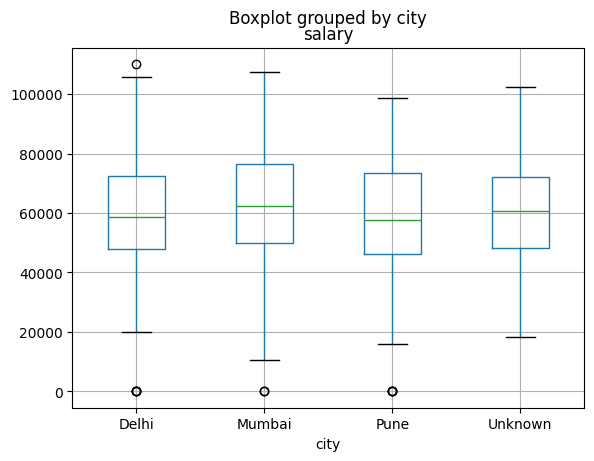

In [50]:
df.boxplot(column="salary", by="city")

- `"Unknown"` city has weird distribution
- One city may dominate salary patterns -> **bias risk**

### Exercise 6
1. Group by `joined_year`
2. Compute:
   - average salary
   - user count
3. Plot or print trends
4. Answer:
   - Do you see sudden jumps?
   - Is `joined_year` safe to use as a feature?

In [51]:
df.groupby("joined_year")["salary"].mean()

joined_year
2014    58134.052632
2015    57776.120000
2016    64848.219512
2017    58079.409091
2018    64124.387755
2019    57419.902439
2020    55736.818182
2021    57197.372093
2022    59445.878049
2023    59486.081081
2024    59265.925926
2025    58771.555556
Name: salary, dtype: float64

In [52]:
df.groupby("joined_year").size()

joined_year
2014    38
2015    50
2016    41
2017    44
2018    49
2019    41
2020    44
2021    43
2022    41
2023    37
2024    27
2025    45
dtype: int64

Any future timestamp = leakage until proven otherwise.

### Exercise 7
1. Compute correlation matrix
2. Identify:
   - strongest correlations
3. Answer:
   - Which correlations might indicate leakage?
   - Why correlation alone is not enough?

In [53]:
df.corr(numeric_only=True)

,user_id,age,salary,experience,joined_year
user_id,1.000000,0.067460,-0.062619,0.000123,0.006838
age,0.067460,1.000000,-0.023772,-0.076890,0.018176
salary,-0.062619,-0.023772,1.000000,0.032468,-0.020685
experience,0.000123,-0.076890,0.032468,1.000000,-0.023006
joined_year,0.006838,0.018176,-0.020685,-0.023006,1.000000


**Observations**
- experience <-> age -> expected
- joined_year correlating with salary -> potential leakage

**Why Correlation Is Dangerous Alone**
- Correlation ≠ causation
- Time-based leakage creates **fake correlations**